# Comparing a Gel's Mechanical Properties in Different Conditions

One objective was to see whether different factors changed which of a gel's mechanical properties and in what way.

The Excel file's expected organization and input formats are as follows :

| dates | ID | cycle | Prop. 1 | Prop. 2 | Prop. 3 | Prop. 4 |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| `yy/mm/dd` | `yy/mm/dd`-`condition`-gel`n` | Cycle `n` | _float_ | _float_ | _float_ | _float_ |

For anonymization, Prop. n is not the literal name of the columns. This should not be an issue because those columns are accessed by their index number. Thus, the first 7 columns should be organized as described above, despite this not being the full shape of the file.

> Further down the line, however, this structure may be subject to change. I did not write the mechanical property extraction functions and so did not control the file's organization nor format. 

In [1]:
from itertools import combinations, chain

import numpy as np
import pandas as pd

from scipy import stats
from statsmodels.stats.multitest import multipletests

import matplotlib as mpl
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams.update({'font.size': 15})

## Preparing the Dataset

In [2]:
df = pd.read_excel("../data/mechanical_properties.xlsx") # replace as needed
display(df.head())

,dates,ID,cycle,Prop. 1,Prop. 2,Prop. 3,Prop. 4
0,26/04/10,26/04/10-F-gel2,Cycle 1,8.157846,7.735445,8.677083,24.121052
1,26/04/10,26/04/10-A-gel2,Cycle 1,7.122960,8.121455,5.466224,6.779579
2,26/04/10,26/04/10-C-gel2,Cycle 1,7.705863,15.406825,18.659818,12.484017
3,26/04/10,26/04/10-B-gel3,Cycle 1,7.640870,12.695311,10.195339,18.246904
4,26/04/10,26/04/10-C-gel3,Cycle 1,8.548567,13.860000,21.061410,13.119965


The current Excel file organization has the gel's condition stored in its ID. This requires iterating through the entire dataframe for every filter by condition. Creating a new column that stores only the gel's condition has at least 2 benefits :

1. It facilitates filtering by condition in the long run.
2. If there are multiple names for the same condition, this quickly groups them together with a general name that you know and define explicitly.

```python
df.insert(2, "condition", condition_names_list)
```

Each element in `conditions_names_list` needs to correspond to a sample in the dataframe, in the same order.

In [ ]:
# automatically create condition column
df.insert(2, "condition", [df.iloc[i]["ID"].split("-")[1] for i in range(df.shape[0])])
display(df.head())

,dates,ID,condition,cycle,Prop. 1,Prop. 2,Prop. 3,Prop. 4
0,26/04/10,26/04/10-F-gel2,F,Cycle 1,8.157846,7.735445,8.677083,24.121052
1,26/04/10,26/04/10-A-gel2,A,Cycle 1,7.122960,8.121455,5.466224,6.779579
2,26/04/10,26/04/10-C-gel2,C,Cycle 1,7.705863,15.406825,18.659818,12.484017
3,26/04/10,26/04/10-B-gel3,B,Cycle 1,7.640870,12.695311,10.195339,18.246904
4,26/04/10,26/04/10-C-gel3,C,Cycle 1,8.548567,13.860000,21.061410,13.119965


## Visualization

For consistency, it would be better to use the same color for a given condition in every plot.

In [4]:
# automatically extract conditions
conditions = []
for sample in list(df["ID"]) :
    c = sample.split("-")[1]
    if c not in conditions : conditions.append(c)
conditions = sorted(conditions)

Ideally, the conditions would be in a logical order (in this case, alphabetical). However, if you have a preferable order, then explicitly define that in a `conditions` list.

In [5]:
# get color maps (using 2 maximizes the number of colors available in the case of many conditions)
plasma_cmap = mpl.colormaps["plasma"]; viridis_cmap = mpl.colormaps["viridis"]

# divide each color map so that there are exactly the same number of colors as there are conditions
s1 = len(conditions)//2; s2 = len(conditions) - s1

plasma_colors = list(plasma_cmap(np.linspace(start=0, stop=0.9, num=s1)))
viridis_colors = list(reversed(list(viridis_cmap(np.linspace(start=0.3, stop=0.9, num=s2)))))
pv_colors = plasma_colors + viridis_colors # add colormaps together

# assign colors
colors = {conditions[i]:pv_colors[i] for i in range(len(conditions))}

In [6]:
# subplot coordinates
plt_idx = {
    4 : (0,0),
    5 : (0,1),
    6 : (1,0),
    7 : (1,1)
}

In [7]:
def scatter_box_plot(selected_conditions, fig_dim=(7.5,7.5), separate_cycles=False) :
    fig, axs = plt.subplots(2,2, figsize=fig_dim)

    if separate_cycles : multicycle_cond = sorted(list({x.split("-")[1] for x in df[df["cycle"] == "Cycle 2"]["ID"].unique()}))   

    for p in range(4,8) :
        bp_val = []

        # plot scatter plots for each condition for 1 property
        for c in selected_conditions :
            if separate_cycles and c in multicycle_cond :
                aux = df[df["condition"] == c]
                for i in range(1,3) :
                    val_lst = aux[aux["cycle"] == f"Cycle {i}"].iloc[:,p]

                    x_scatter = [f"{c}-{i}"] * len(val_lst)

                    axs[plt_idx[p]].scatter(x_scatter, val_lst, color=colors[c], alpha=0.5)

                    bp_val.append(val_lst)
            else : 
                val_lst = df[df["condition"] == c].iloc[:,p]
                x_scatter = [c] * len(val_lst)

                axs[plt_idx[p]].scatter(x_scatter, val_lst, color=colors[c], alpha=0.5)
                
                bp_val.append(val_lst)
        
        if separate_cycles : 
            aux = []
            for c in selected_conditions :
                if c in multicycle_cond : aux += [f"{c}-{i}" for i in range(1,3)]
                else : aux.append(c)
    
        # plot boxplots for all conditions for 1 property
        bp = axs[plt_idx[p]].boxplot(
            bp_val,
            tick_labels=aux if separate_cycles else selected_conditions,
            positions=range(len(aux) if separate_cycles else len(selected_conditions)),
            patch_artist=True
        )

        for patch, c in zip(bp["boxes"], aux if separate_cycles else selected_conditions) :
            patch.set_facecolor(colors[c.split("-")[0]])
            patch.set_alpha(0.25)

        for median in bp["medians"] :
            median.set(color="red", linewidth=1)

        axs[plt_idx[p]].set_ylabel(df.iloc[:,p].name)
        axs[plt_idx[p]].grid(axis="y", linewidth=0.5)

    plt.tight_layout()
    plt.show()

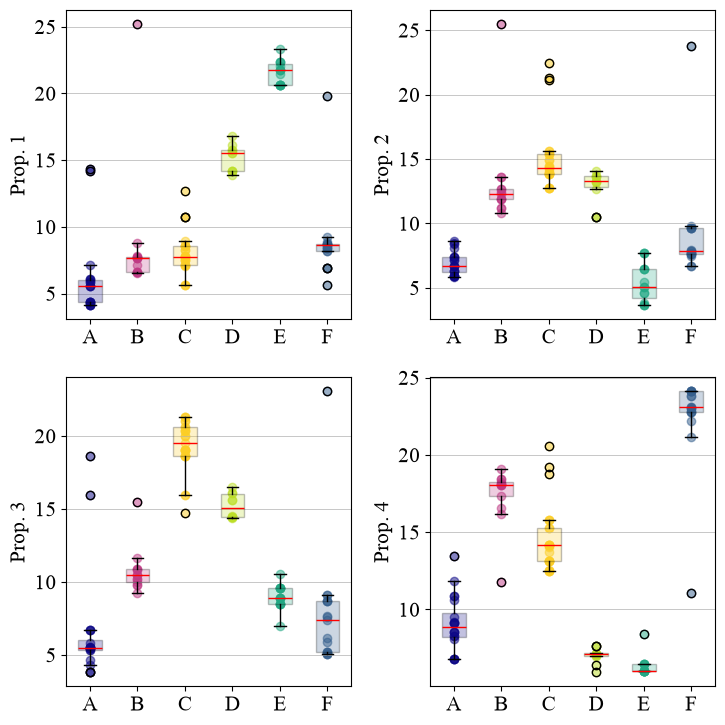

In [8]:
scatter_box_plot(conditions)

It's possible that a gel's mechanical properties differ between cycles (depending on the experimental procedure) so it could be interesting to separate the gel by condition and by cycle.

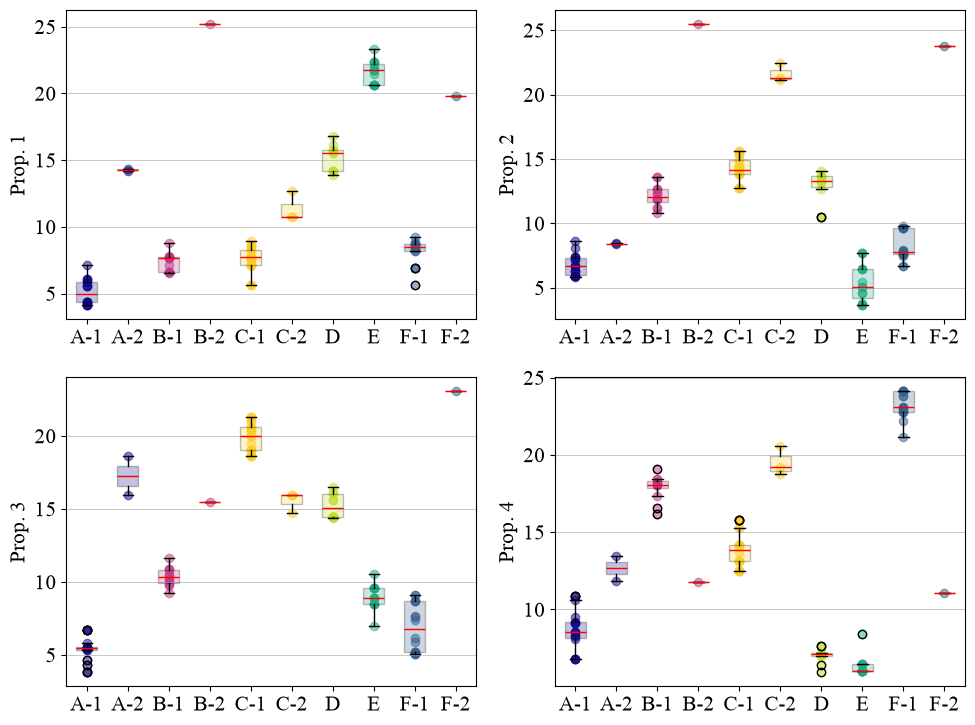

In [9]:
scatter_box_plot(conditions, fig_dim=(10,7.5), separate_cycles=True)

And of course, we do not always need to compare all conditions at the same time every time. Selecting only the conditions of interest improves lisibility.

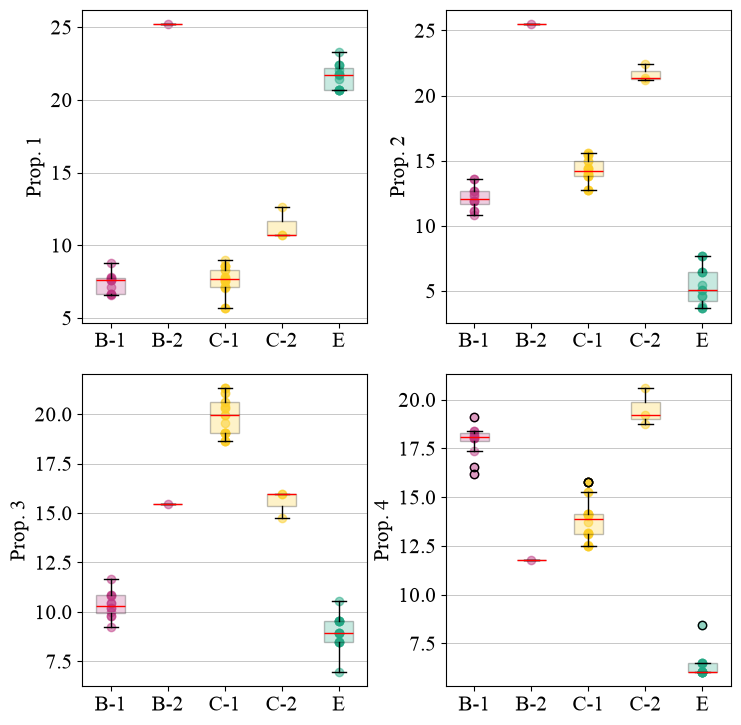

In [10]:
scatter_box_plot(["B","C","E"], separate_cycles=True)

## Statistical Tests

Despite the visual differences, it could be useful to test if there are statistically significant differences between conditions. In this case, we would use the Kruskal-Wallis and the Mann-Whitney tests because we do not know whether the gels' mechanical properties are normally distributed or not.

In [11]:
def significance_test(selected_conditions, separate_cycles=False) :

    if separate_cycles : multicycle_cond = sorted(list({x.split("-")[1] for x in df[df["cycle"] == "Cycle 2"]["ID"].unique()}))

    for p in range(4,8) :
        print(df.columns[p])
        if separate_cycles :
            groups = dict()
            for c in selected_conditions :
                c_val = df[df["condition"] == c]
                if c in multicycle_cond :
                    for i in range(1,3) :
                        groups[f"{c}-{i}"] = c_val[c_val["cycle"] == f"Cycle {i}"].iloc[:,p]
                else : groups[f"{c}"] = c_val.iloc[:,p]
        else : groups = {c:df[df["condition"] == c].iloc[:,p] for c in selected_conditions}

        _, p_val_kw = stats.kruskal(*list(groups.values()))
        print(f"Kruskal-Wallis p-value : {round(p_val_kw, 5)}", end=" ")

        c_lst = []
        for c, lst in groups.items() :
            c_lst += [c] * len(lst)

        if p_val_kw < 0.05 :
            print("-- significant")
            tmp_data = pd.DataFrame({
                "value" : chain(*list(groups.values())),
                "group" : c_lst
            })

            comparisons = list(combinations(list(groups.keys()), 2));
            raw_p_val = []; u_stats = []

            for c1,c2 in comparisons :
                g1, g2 = groups[c1], groups[c2]
                stat, p_val_mw = stats.mannwhitneyu(g1, g2, alternative="two-sided")

                u_stats.append(stat)
                raw_p_val.append(p_val_mw)
            
            reject, adj_p_val, _, _ = multipletests(raw_p_val, alpha=0.05, method="bonferroni")

            mw_res = pd.DataFrame({
                "Comparison" : comparisons,
                "U Statistic" : u_stats,
                "Raw P-Values" : raw_p_val,
                "Adjusted P-Values" : adj_p_val,
                "Significance (Reject H0)" : reject
            })
            print("Mann-Whitney")
            display(mw_res[["Comparison", "Significance (Reject H0)"]])
        else : print("-- not significant")
        print()
    return mw_res

For simplicity, only the comparison and the True/False reject H0 result are immediately displayed, but all the stats can be saved in a variable for further verification.

In [12]:
res = significance_test(["B", "C", "E"], separate_cycles=True)

Prop. 1
Kruskal-Wallis p-value : 0.0 -- significant
Mann-Whitney


,Comparison,Significance (Reject H0)
0,"(B-1, B-2)",False
1,"(B-1, C-1)",False
2,"(B-1, C-2)",False
3,"(B-1, E)",True
4,"(B-2, C-1)",False
5,"(B-2, C-2)",False
6,"(B-2, E)",False
7,"(C-1, C-2)",False
8,"(C-1, E)",True
9,"(C-2, E)",False



Prop. 2
Kruskal-Wallis p-value : 0.0 -- significant
Mann-Whitney


,Comparison,Significance (Reject H0)
0,"(B-1, B-2)",False
1,"(B-1, C-1)",True
2,"(B-1, C-2)",False
3,"(B-1, E)",True
4,"(B-2, C-1)",False
5,"(B-2, C-2)",False
6,"(B-2, E)",False
7,"(C-1, C-2)",False
8,"(C-1, E)",True
9,"(C-2, E)",False



Prop. 3
Kruskal-Wallis p-value : 0.0 -- significant
Mann-Whitney


,Comparison,Significance (Reject H0)
0,"(B-1, B-2)",False
1,"(B-1, C-1)",True
2,"(B-1, C-2)",False
3,"(B-1, E)",True
4,"(B-2, C-1)",False
5,"(B-2, C-2)",False
6,"(B-2, E)",False
7,"(C-1, C-2)",False
8,"(C-1, E)",True
9,"(C-2, E)",False



Prop. 4
Kruskal-Wallis p-value : 0.0 -- significant
Mann-Whitney


,Comparison,Significance (Reject H0)
0,"(B-1, B-2)",False
1,"(B-1, C-1)",True
2,"(B-1, C-2)",False
3,"(B-1, E)",True
4,"(B-2, C-1)",False
5,"(B-2, C-2)",False
6,"(B-2, E)",False
7,"(C-1, C-2)",False
8,"(C-1, E)",True
9,"(C-2, E)",False
